# HW1：COVID-19 阳性率回归预测

使用多层感知机（MLP）根据美国各州与调查特征预测 `tested_positive`。运行本 notebook 后会重新生成 `pred.csv`，并在 `results/` 中保存训练曲线和预测分布图。

Device: cuda
Input features: 87
Best validation MSE: 0.880995


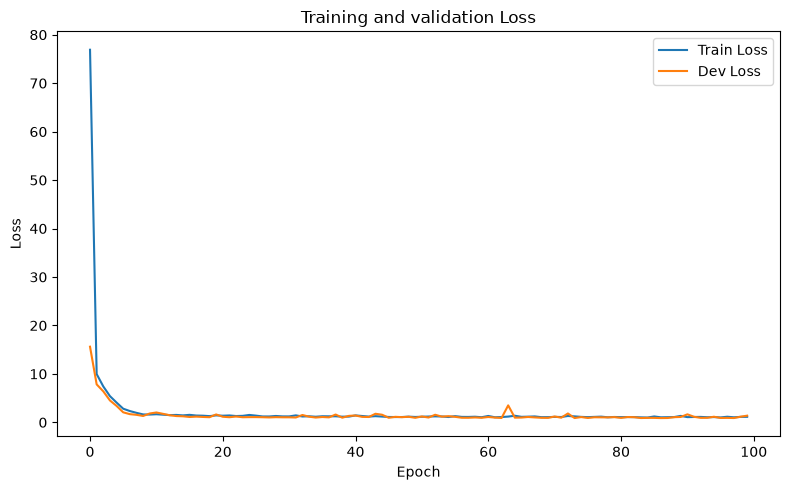

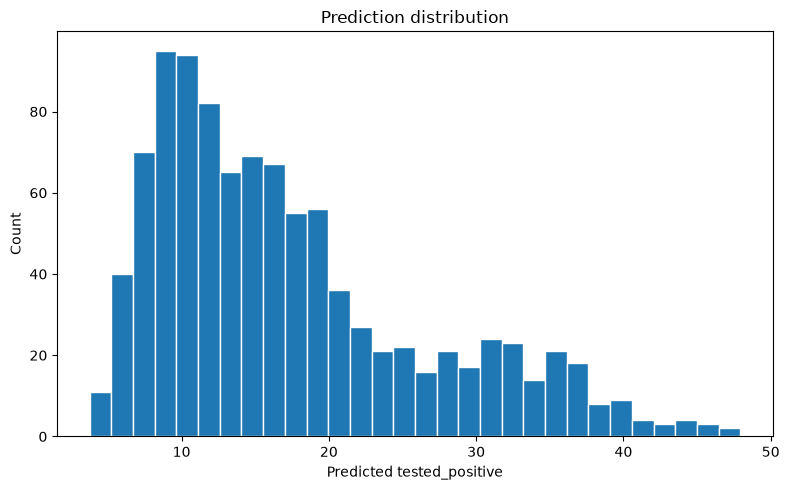

Predictions saved: 997 rows -> pred.csv
Result figures saved to: results


In [1]:
import torch
import torch.nn as nn

from torch.utils.data import Dataset,DataLoader

import numpy as np
import csv
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

myseed =42069

torch.backends.cudnn.deterministic =True
torch.backends.cudnn.benchmark =False

np.random.seed(myseed)
torch.manual_seed(myseed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)
    
def get_device():
    return 'cuda' if torch.cuda.is_available() else 'cpu'
# 设置疫情数据集，为后续loader做准备    
class COVID19Dataset(Dataset):
    def __init__(self,x,y=None):
        self.x=torch.FloatTensor(x)
        # 考虑到测试集y为空的情况
        if y is None:
            self.y=y
        else:
            self.y =torch.FloatTensor(y)

    def __getitem__(self,idx):
        if self.y is None:
            return self.x[idx]
        else :
            return self.x[idx],self.y[idx]
            
    def __len__(self): 
        return len(self.x)

# 定义一个准备加载数据的函数，为后续生成dataloader做准备
def prep_dataloader(path,mode,batch_size,n_jobs=0,target_only=False):
    # 这里用with会自动帮我关上文件
    with open(path,'r') as fp:
        data = list(csv.reader(fp))
        data =np.array(data[1:])[:,1:].astype(float)
    # 使用特征选择
    if not target_only:
        if mode == 'test':
            feats=list(range(data.shape[1]))
        else:
            feats=list(range(data.shape[1]-1))
    else:
        feats=list(range(40))+[57,75]

    if mode == 'test':
        dataset = COVID19Dataset(data[:,feats])
    else:
        target =data[:,-1]

        if mode == 'train':
            indices =[i for i in range(len(data)) if i%10 !=0]
        elif mode == 'dev':
            indices = [i for i in range(len(data)) if i%10 ==0]

        dataset =COVID19Dataset(data[indices][:,feats],target[indices])

    dataloader = DataLoader(
        dataset,
        batch_size,
        shuffle=(mode == 'train'),
        drop_last=False,
        num_workers=n_jobs,
        pin_memory=torch.cuda.is_available()
    )        

    return dataloader
# 开始生成训练集（train_loader），检验集(dev_loader)，测试集(text_loader)

train_path='./covid_train.csv'
test_path='./covid_test.csv'
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

batch_size=32
# 训练集
train_loader =prep_dataloader(
    train_path,
    'train',
    batch_size
)
# 检验集
dev_loader =prep_dataloader(
    train_path,
    'dev',
    batch_size
)
# 测试集
test_loader = prep_dataloader(
    test_path,
    'test',
    batch_size
)
class My_Model(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )

    def forward(self, x):
        return self.layers(x).squeeze(1)

device = get_device()
input_dim = train_loader.dataset.x.shape[1]
model = My_Model(input_dim=input_dim).to(device)

# 定义损失函数和优化器

criterion =nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

train_losses = []
dev_losses =[]

best_dev_loss =float('inf')
# 开始训练模型
for epoch in range(100):
    # 训练模型
    model.train()
    total_train_loss=0.0
    for inputs,labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        y_pred=model(inputs)

        loss = criterion(y_pred, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_train_loss+=loss.item() * inputs.size(0)
        
    train_loss=total_train_loss/len(train_loader.dataset) 
    train_losses.append(train_loss)

    # 检验训练效果
    model.eval()

    total_dev_loss=0.0

    with torch.no_grad():

        for inputs,labels in dev_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            y_pred =model(inputs)

            loss = criterion(y_pred, labels)

            total_dev_loss+=loss.item() * inputs.size(0)
    dev_loss=total_dev_loss/len(dev_loader.dataset)
    dev_losses.append(dev_loss)
    # 保存最佳模型

    if dev_loss <best_dev_loss:
        best_dev_loss=dev_loss
        torch.save(
            model.state_dict(),
            'best_model.pth'
        )

print(f'Device: {device}')
print(f'Input features: {input_dim}')
print(f'Best validation MSE: {best_dev_loss:.6f}')

# 画出训练图像，看看是否过拟合

plt.figure(figsize=(8,5))

plt.plot(train_losses,label='Train Loss')
plt.plot(dev_losses,label='Dev Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and validation Loss')

plt.legend()
plt.tight_layout()
plt.savefig(results_dir / 'training_curve.png', dpi=160, bbox_inches='tight')
plt.show()

# 下面开始进行预测
model.load_state_dict(
    torch.load('best_model.pth', map_location=device, weights_only=True)
)            
model.eval()

# 准备一个空列表
predictions =[]

with torch.no_grad():
    for inputs in test_loader:

        inputs =inputs.to(device)

        y_pred=model(inputs)

        predictions.extend(y_pred.cpu().numpy())

# 写一个保存作为CSV函数 
def save_pred(predictions,file):
    with open(file,'w',newline='') as fp:
        writer = csv.writer(fp)

        writer.writerow(['id','tested_positive'])

        for i,pred in enumerate(predictions):
            writer.writerow([i,float(pred)])
save_pred(predictions, 'pred.csv')

plt.figure(figsize=(8, 5))
plt.hist(predictions, bins=30, edgecolor='white')
plt.xlabel('Predicted tested_positive')
plt.ylabel('Count')
plt.title('Prediction distribution')
plt.tight_layout()
plt.savefig(results_dir / 'prediction_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

print(f'Predictions saved: {len(predictions)} rows -> pred.csv')
print(f'Result figures saved to: {results_dir}')

In [2]:
print('Prediction file: pred.csv')

Prediction file: pred.csv
